In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
df = pd.read_csv('data/pokemon.csv')

In [136]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [138]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


## Distribution pokemon types

### 🔎 Step by step:

1. `df['Type 1']`
- Selects the column `"Type 1"` from your Pokémon dataset.
- Example: values like `"Grass"`, `"Fire"`, `"Water"`, etc.

2. `.value_counts()`
- Counts how many times each type appears.
- Returns a Series where the index = Pokémon type, value = count.
- Example:

```
Water    112
Normal   98
Grass    70
Fire     55
...
```

3. `.plot(kind='pie', ...)`
- Tells pandas to make a pie chart using Matplotlib.
- Since the object is a Series (type counts), the pie chart will show the proportion of each Pokémon type.

4. `autopct='%1.1f%%'`
- Adds percentage labels on the pie slices.
- `%1.1f%%` → format string:
  - `1.1f` → show 1 digit before decimal, 1 digit after decimal.
  - `%%` → literal `%` sign.
- Example: `"12.5%"`.

5. `cmap='tab20c'`
- Colormap (color theme) from Matplotlib.
- `'tab20c'` is a palette with 20 distinct colors — helps differentiate categories.

6. `figsize=(10, 8)`
- Sets the figure size (width=10, height=8 inches).
- Larger figure → bigger, more readable chart.

<Axes: ylabel='count'>

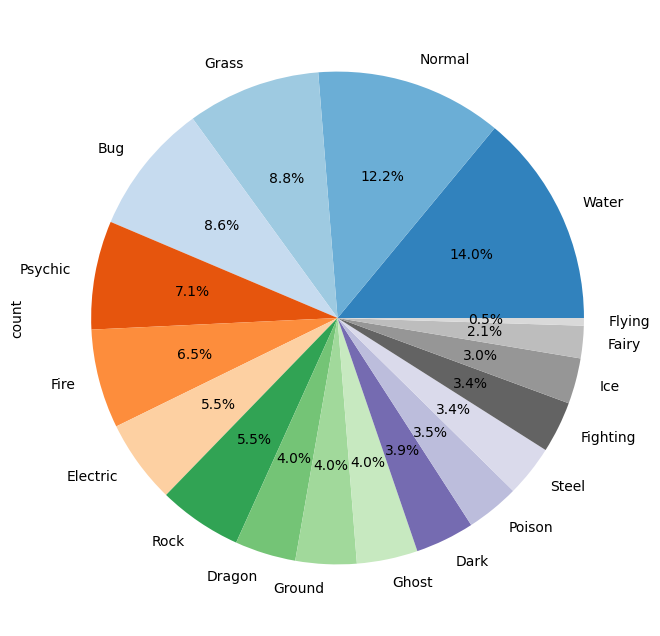

In [139]:
df['Type 1'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='tab20c', figsize=(10, 8))

## Distribution of Pokemon Totals

<Axes: ylabel='Frequency'>

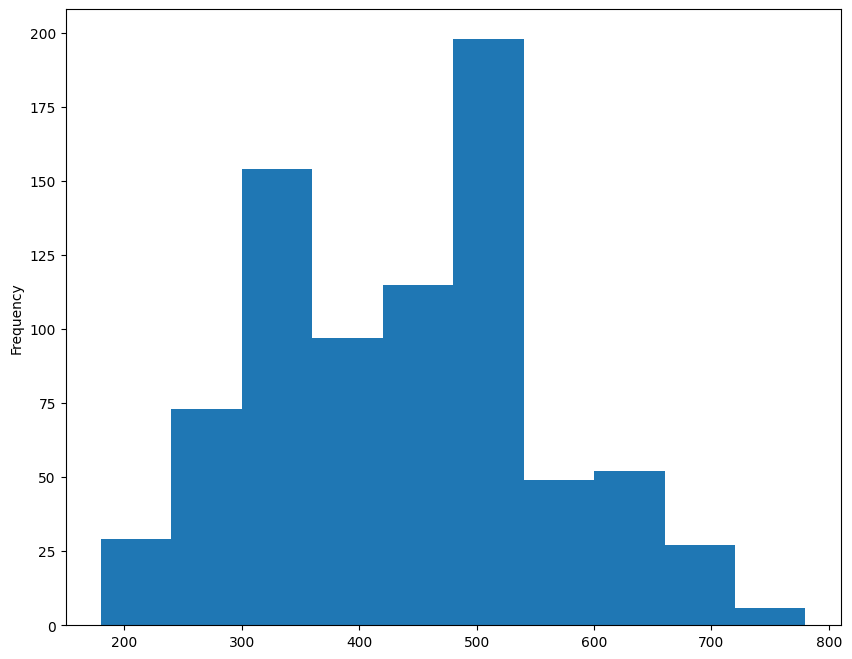

In [140]:
df['Total'].plot(kind='hist', figsize=(10,8))

<Axes: >

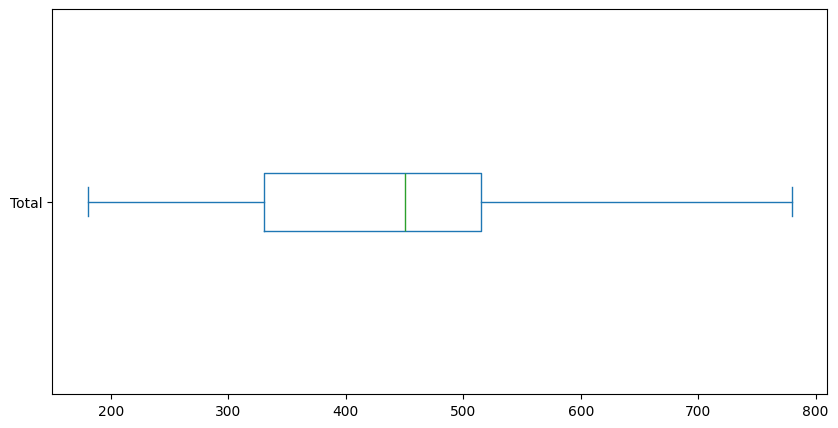

In [141]:
df['Total'].plot(kind='box', vert=False, figsize=(10, 5))

## Distribution of Legendary Pokemons

<Axes: ylabel='count'>

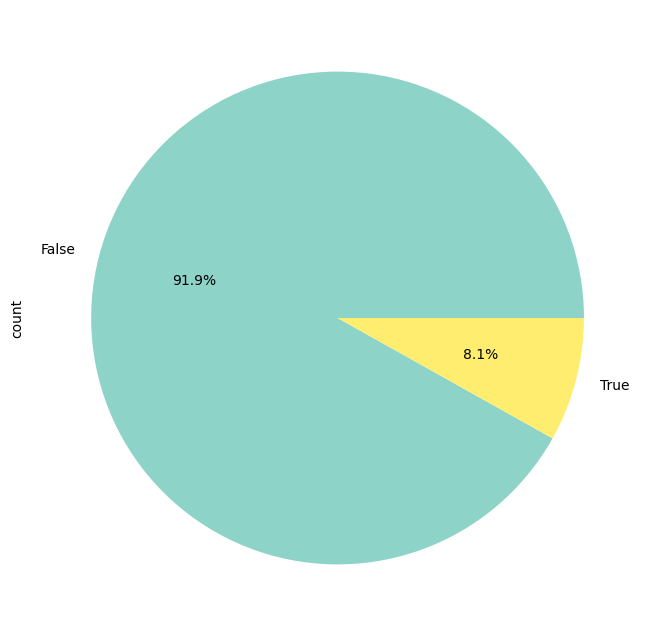

In [142]:
df['Legendary'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Set3', figsize=(10,8))

### Basic Filtering
##### Let's start with a few simple activities regarding filtering.

#### 1. How many Poekmons exists with an `Attack` value greater than 150?

<Axes: xlabel='Attack'>

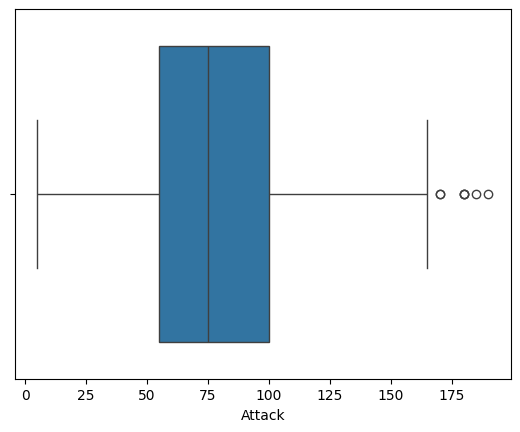

In [143]:
sns.boxplot(data=df, x='Attack')

### 1. `filt = df[df['Attack'] > 150]`
- Here, `df['Attack'] > 150` creates a boolean mask (a Series of True/False).
- Wrapping it inside `df[...]` immediately filters the DataFrame.
- ✅ So filt is now a filtered DataFrame containing only the rows where Attack > 150.

```
     Name        Attack
382  Groudon      180
...
```

### 2. `filt = df['Attack'] > 150`
- Here, filt is just the boolean Series mask itself.
- Example output:

```
0    False
1    False
2    False
3    False
4    False
...
382   True
383  False
dtype: bool
```

- ✅ We then pass this mask back into .loc or df[...] to filter the rows, see below.

`df.loc[filt, 'Name']`

In [144]:
(df['Attack'] > 150).sum()

np.int64(18)

In [145]:
filt = df['Attack'] > 150
df.loc[filt]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
137,127,PinsirMega Pinsir,Bug,Flying,600,65,155,120,65,90,105,1,False
141,130,GyaradosMega Gyarados,Water,Dark,640,95,155,109,70,130,81,1,False
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
232,214,HeracrossMega Heracross,Bug,Fighting,600,80,185,115,40,105,75,2,False
268,248,TyranitarMega Tyranitar,Rock,Dark,700,100,164,150,95,120,71,2,False
279,257,BlazikenMega Blaziken,Fire,Fighting,630,80,160,80,130,80,100,3,False
313,289,Slaking,Normal,NaN,670,150,160,100,95,65,100,3,False
387,354,BanetteMega Banette,Ghost,NaN,555,64,165,75,93,83,75,3,False
424,383,GroudonPrimal Groudon,Ground,Fire,770,100,180,160,150,90,90,3,True
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True


In [146]:
df.query('Attack > 150')

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
137,127,PinsirMega Pinsir,Bug,Flying,600,65,155,120,65,90,105,1,False
141,130,GyaradosMega Gyarados,Water,Dark,640,95,155,109,70,130,81,1,False
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
232,214,HeracrossMega Heracross,Bug,Fighting,600,80,185,115,40,105,75,2,False
268,248,TyranitarMega Tyranitar,Rock,Dark,700,100,164,150,95,120,71,2,False
279,257,BlazikenMega Blaziken,Fire,Fighting,630,80,160,80,130,80,100,3,False
313,289,Slaking,Normal,NaN,670,150,160,100,95,65,100,3,False
387,354,BanetteMega Banette,Ghost,NaN,555,64,165,75,93,83,75,3,False
424,383,GroudonPrimal Groudon,Ground,Fire,770,100,180,160,150,90,90,3,True
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True


#### 2. Select all pokemons with a Speed of `10` or less.

<Axes: xlabel='Speed'>

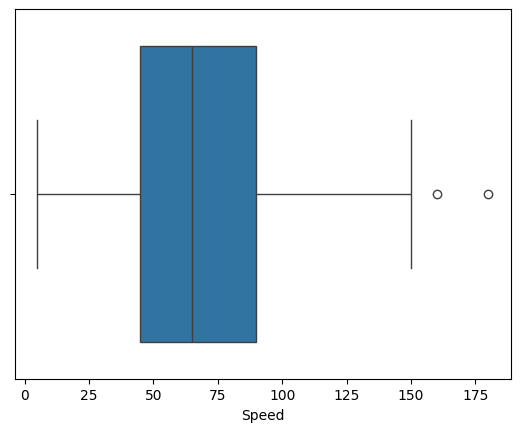

In [147]:
sns.boxplot(data=df, x='Speed')

In [148]:
df['Speed'] <= 10.  # Boolean values

0      False
1      False
2      False
3      False
4      False
       ...  
795    False
796    False
797    False
798    False
799    False
Name: Speed, Length: 800, dtype: bool

In [149]:
speed_pokemon_df = df.loc[df['Speed'] <= 10]
speed_pokemon_df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
230,213,Shuckle,Bug,Rock,505,20,10,230,10,230,5,2,False
359,328,Trapinch,Ground,NaN,290,45,100,45,45,45,10,3,False
486,438,Bonsly,Rock,NaN,290,50,80,95,10,45,10,4,False
495,446,Munchlax,Normal,NaN,390,135,85,40,40,85,5,4,False
658,597,Ferroseed,Grass,Steel,305,44,50,91,24,86,10,5,False


#### 3. How many pokemons have a `Sp. Def` value of 25 or less?

In [150]:
df['Sp. Def'] <= 25

0      False
1      False
2      False
3      False
4      False
       ...  
795    False
796    False
797    False
798    False
799    False
Name: Sp. Def, Length: 800, dtype: bool

In [151]:
(df['Sp. Def'] <= 25).sum()

np.int64(18)

In [152]:
df.loc[df['Sp. Def'] <= 25]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
13,10,Caterpie,Bug,NaN,195,45,30,35,20,20,45,1,False
14,11,Metapod,Bug,NaN,205,50,20,55,25,25,30,1,False
16,13,Weedle,Bug,Poison,195,40,35,30,20,20,50,1,False
17,14,Kakuna,Bug,Poison,205,45,25,50,25,25,35,1,False
44,39,Jigglypuff,Normal,Fairy,270,115,45,20,45,25,20,1,False
97,90,Shellder,Water,NaN,305,30,65,100,45,25,40,1,False
106,98,Krabby,Water,NaN,325,30,105,90,25,25,50,1,False
125,116,Horsea,Water,NaN,295,30,40,70,70,25,60,1,False
139,129,Magikarp,Water,NaN,200,20,10,55,15,20,80,1,False
188,174,Igglybuff,Normal,Fairy,210,90,30,15,40,20,15,2,False


#### 4. Select all the Legendary Pokemons.

In [153]:
df['Legendary'].sum()
# this will display the total number of True values.

np.int64(65)

- [False, True, False, True]

negation '~' of above will be :-

- [True, False, True, False]

In [154]:
legendary_df = df['Legendary'] == True
df.loc[legendary_df]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
156,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
157,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True
158,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True
162,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
164,150,MewtwoMega Mewtwo Y,Psychic,NaN,780,106,150,70,194,120,140,1,True
262,243,Raikou,Electric,NaN,580,90,85,75,115,100,115,2,True
263,244,Entei,Fire,NaN,580,115,115,85,90,75,100,2,True
264,245,Suicune,Water,NaN,580,100,75,115,90,115,85,2,True
269,249,Lugia,Psychic,Flying,680,106,90,130,90,154,110,2,True


In [155]:
df.loc[~legendary_df]
# this will give us all the legendary pokemons with value 'False'

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,711,GourgeistSuper Size,Ghost,Grass,494,85,100,122,58,75,54,6,False
788,712,Bergmite,Ice,NaN,304,55,69,85,32,35,28,6,False
789,713,Avalugg,Ice,NaN,514,95,117,184,44,46,28,6,False
790,714,Noibat,Flying,Dragon,245,40,30,35,45,40,55,6,False


#### 5. Find the Outlier
##### Find the pokemon that is clearly an outlier in terms of Attack/Defense

In [156]:
df['Defense'].max()

np.int64(230)

In [157]:
df['Attack'].min()

np.int64(5)

Text(150, 10, "Who's this guy?")

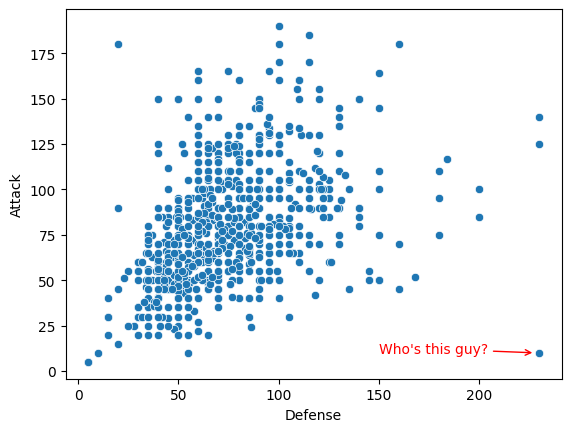

In [158]:
ax = sns.scatterplot(data=df, x='Defense', y='Attack')
ax.annotate("Who's this guy?", xy=(228, 10), xytext=(150,10), color='red', 
            arrowprops=dict(arrowstyle='->', color='red'))

#### Let’s make it automatic so you don’t need to manually look up (228, 10) again.

##### Since we’re plotting Defense vs Attack, let’s find the outliers (Pokémon with extremely high Defense but very low Attack, or vice versa).

In [159]:
weird_pokemon = df.loc[df['Defense'].idxmax()]
weird_pokemon[['Name', 'Attack', 'Defense']]

Name       SteelixMega Steelix
Attack                     125
Defense                    230
Name: 224, dtype: object

Text(180, 145, "Who's this guy?")

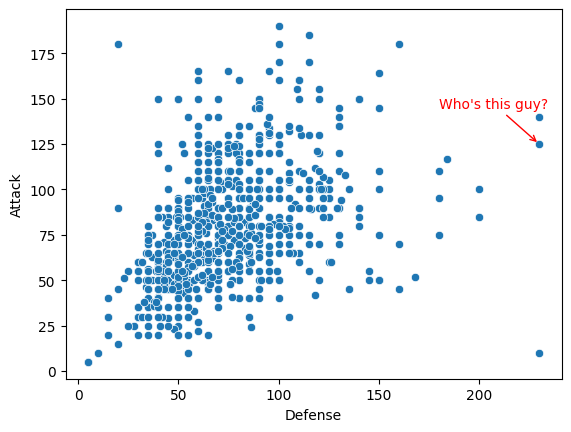

In [160]:
ax = sns.scatterplot(data=df, x='Defense', y='Attack')
ax.annotate("Who's this guy?", xy=(weird_pokemon['Defense'], weird_pokemon['Attack']), 
    xytext=(weird_pokemon['Defense']-50, weird_pokemon['Attack'] + 20), color='red',
    arrowprops=dict(arrowstyle='->', color='red'))

In [161]:
df.sort_values(by=['Defense', 'Attack'], ascending=[False, True]).head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
230,213,Shuckle,Bug,Rock,505,20,10,230,10,230,5,2,False
224,208,SteelixMega Steelix,Steel,Ground,610,75,125,230,55,95,30,2,False
333,306,AggronMega Aggron,Steel,NaN,630,70,140,230,60,80,50,3,False
223,208,Steelix,Steel,Ground,510,75,85,200,55,65,30,2,False
414,377,Regirock,Rock,NaN,580,80,100,200,50,100,50,3,True


In [162]:
max_defense = df['Defense'].max()
min_attack = df[(df['Defense'] == max_defense)]['Attack'].min()

pokemon_maxdefense_minattack = df[(df['Defense'] == max_defense) & (df['Attack'] == min_attack)]
pokemon_maxdefense_minattack['Name']
# df.loc[(df['Defense'])]

230    Shuckle
Name: Name, dtype: object

### Advanced Selection
##### Now let's use boolean operators to create more advanced expressions

#### 6. How many `Fire-Flying` pokemons are there?

In [163]:
fire_flying_pokemon = ((df['Type 1'] == 'Fire') & (df['Type 2'] == 'Flying'))
fire_flying_pokemon.sum()

np.int64(6)

In [164]:
df.loc[fire_flying_pokemon]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
158,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True
270,250,Ho-oh,Fire,Flying,680,106,130,90,110,154,90,2,True
730,662,Fletchinder,Fire,Flying,382,62,73,55,56,52,84,6,False
731,663,Talonflame,Fire,Flying,499,78,81,71,74,69,126,6,False


#### 7. How many `Poison` pokemons are across both types?

In [169]:
poison_pokemons = ((df['Type 1'] == 'Poison') | (df['Type 2'] == 'Poison'))
poison_pokemons.sum()

np.int64(62)

In [175]:
df.loc[poison_pokemons]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
16,13,Weedle,Bug,Poison,195,40,35,30,20,20,50,1,False
17,14,Kakuna,Bug,Poison,205,45,25,50,25,25,35,1,False
18,15,Beedrill,Bug,Poison,395,65,90,40,45,80,75,1,False
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False
28,23,Ekans,Poison,NaN,288,35,60,44,40,54,55,1,False
29,24,Arbok,Poison,NaN,438,60,85,69,65,79,80,1,False


#### 8. What pokemon of `Type 1` Ice has the strongest defense?

In [191]:
strongest_ice = df[df['Type 1'] == 'Ice']
strongest_ice.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
133,124,Jynx,Ice,Psychic,455,65,50,35,115,95,95,1,False
156,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
238,220,Swinub,Ice,Ground,250,50,50,40,30,30,50,2,False
239,221,Piloswine,Ice,Ground,450,100,100,80,60,60,50,2,False
243,225,Delibird,Ice,Flying,330,45,55,45,65,45,75,2,False


In [192]:
df.loc[df['Type 1'] == 'Ice', 'Defense'].max()

np.int64(184)

In [203]:
df.loc[
  (df['Type 1'] == 'Ice') &
  (df['Defense'] == df.loc[df['Type 1'] == 'Ice', 'Defense'].max())
]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
789,713,Avalugg,Ice,NaN,514,95,117,184,44,46,28,6,False


#### 9. What is the most common type of Legendary pokemon?

In [206]:
df.loc[df['Legendary'], 'Type 1'].value_counts()

Type 1
Psychic     14
Dragon      12
Fire         5
Electric     4
Water        4
Rock         4
Steel        4
Ground       4
Grass        3
Ice          2
Normal       2
Ghost        2
Dark         2
Flying       2
Fairy        1
Name: count, dtype: int64

<Axes: ylabel='count'>

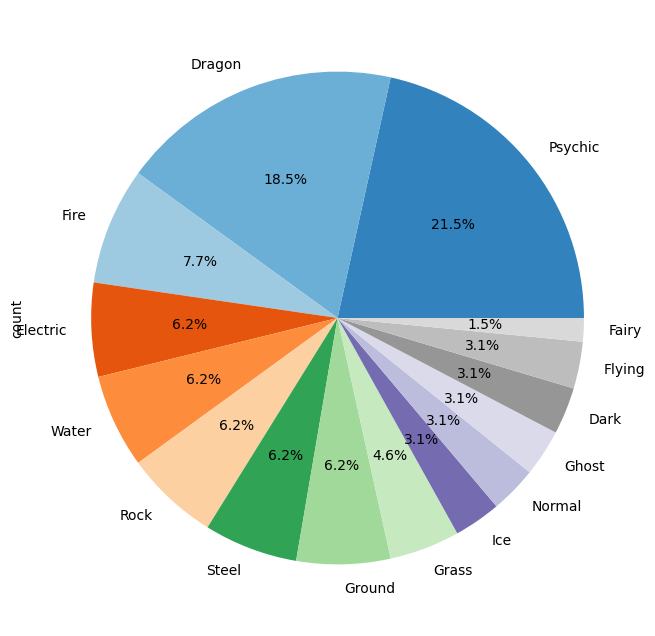

In [210]:
df.loc[df['Legendary'], 'Type 1'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='tab20c', figsize=(10, 8))

<Axes: xlabel='Type 1'>

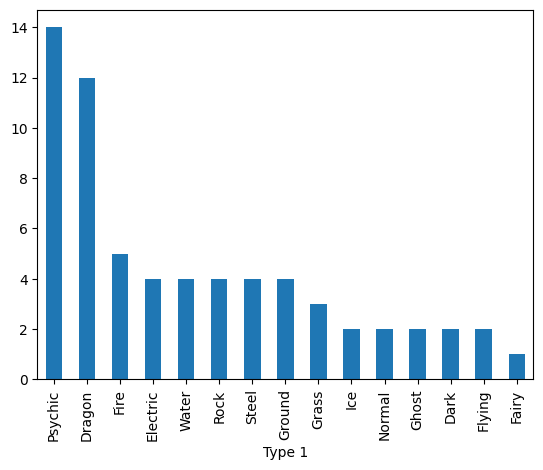

In [211]:
df.loc[df['Legendary'], 'Type 1'].value_counts().plot(kind='bar')

#### 10. What's the most powerful pokemon from the first 3 generations of type water?

In [212]:
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [245]:
df.loc[
  (df['Type 1'] == 'Water') &
  (df['Generation'].isin([1, 2, 3]))
].sort_values(by='Total', ascending=False).head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
422,382,KyogrePrimal Kyogre,Water,NaN,770,100,150,90,180,160,90,3,True
421,382,Kyogre,Water,NaN,670,100,100,90,150,140,90,3,True
141,130,GyaradosMega Gyarados,Water,Dark,640,95,155,109,70,130,81,1,False
283,260,SwampertMega Swampert,Water,Ground,635,100,150,110,95,110,70,3,False
12,9,BlastoiseMega Blastoise,Water,NaN,630,79,103,120,135,115,78,1,False


In [244]:
df['Generation'].isin([1, 2, 3]).sum()

np.int64(432)

In [240]:
# Above written code is alternative of this:-

(
  (df['Generation'] == 1) |
  (df['Generation'] == 2) |
  (df['Generation'] == 3) 
).sum()

np.int64(432)

#### 11. What is most powerful dragon from the last two generations?

In [254]:
df.loc[
  ((df['Type 1'] == 'Dragon') |
  (df['Type 2'] == 'Dragon')) &
  (df['Generation'].isin([5, 6]))
].sort_values(by='Total', ascending=False)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
711,646,KyuremBlack Kyurem,Dragon,Ice,700,125,170,100,120,90,95,5,True
712,646,KyuremWhite Kyurem,Dragon,Ice,700,125,120,90,170,100,95,5,True
706,643,Reshiram,Dragon,Fire,680,100,120,100,150,120,90,5,True
707,644,Zekrom,Dragon,Electric,680,100,150,120,120,100,90,5,True
710,646,Kyurem,Dragon,Ice,660,125,130,90,130,90,95,5,True
776,706,Goodra,Dragon,NaN,600,90,100,70,110,150,80,6,False
794,718,Zygarde50% Forme,Dragon,Ground,600,108,100,121,81,95,95,6,True
696,635,Hydreigon,Dark,Dragon,600,92,105,90,125,90,98,5,False
673,612,Haxorus,Dragon,NaN,540,76,147,90,60,70,97,5,False
791,715,Noivern,Flying,Dragon,535,85,70,80,97,80,123,6,False


In [263]:
# Another way of achieving above results

df.query(
  "`Type 1` == 'Dragon' or `Type 2` == 'Dragon' and Generation in [5, 6]"
).sort_values(by='Total', ascending=False).head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True
711,646,KyuremBlack Kyurem,Dragon,Ice,700,125,170,100,120,90,95,5,True
494,445,GarchompMega Garchomp,Dragon,Ground,700,108,170,115,120,95,92,4,False
409,373,SalamenceMega Salamence,Dragon,Flying,700,95,145,130,120,90,120,3,False
712,646,KyuremWhite Kyurem,Dragon,Ice,700,125,120,90,170,100,95,5,True


#### 12. Select the most powerful fire type pokemon

In [264]:
df.loc[
  (df['Type 1'] == 'Fire') &
  (df['Attack'] >= 100)
].sort_values(by='Attack', ascending=False)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
279,257,BlazikenMega Blaziken,Fire,Fighting,630,80,160,80,130,80,100,3,False
615,555,DarmanitanStandard Mode,Fire,NaN,480,105,140,55,30,55,95,5,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
147,136,Flareon,Fire,NaN,525,65,130,60,95,110,65,1,False
270,250,Ho-oh,Fire,Flying,680,106,130,90,110,154,90,2,True
559,500,Emboar,Fire,Fighting,528,110,123,65,100,65,65,5,False
278,257,Blaziken,Fire,Fighting,530,80,120,70,110,70,80,3,False
354,323,CameruptMega Camerupt,Fire,Ground,560,70,120,100,145,105,20,3,False
263,244,Entei,Fire,NaN,580,115,115,85,90,75,100,2,True
64,59,Arcanine,Fire,NaN,555,90,110,80,100,80,95,1,False


#### 13. Select all Water type and Flying type pokemons

In [265]:
df.loc[
  (df['Type 1'] == 'Water') &
  (df['Type 2'] == 'Flying')
]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
140,130,Gyarados,Water,Flying,540,95,125,79,60,100,81,1,False
244,226,Mantine,Water,Flying,465,65,40,70,80,140,70,2,False
301,278,Wingull,Water,Flying,270,40,30,30,55,30,85,3,False
302,279,Pelipper,Water,Flying,430,60,50,100,85,70,65,3,False
508,458,Mantyke,Water,Flying,345,45,20,50,60,120,50,4,False
641,580,Ducklett,Water,Flying,305,62,44,50,44,50,55,5,False
642,581,Swanna,Water,Flying,473,75,87,63,87,63,98,5,False


#### 14. Select specifics columns of Legendary pokemons of type fire.

In [267]:
legendary_fire_df = df.loc[
  (df['Type 1'] == 'Fire') &
  (df['Legendary'] == True)
]

In [268]:
legendary_fire_df[['Name', 'Attack', 'Generation', 'Legendary']]

,Name,Attack,Generation,Legendary
158,Moltres,100,1,True
263,Entei,115,2,True
270,Ho-oh,130,2,True
542,Heatran,90,4,True
799,Volcanion,110,6,True


#### 15. Select Slow and Fast pokemons
##### This is the distribution of speed of the pokemons. The red lines indicate those bottom 5% and top 5% pokemons by speed:

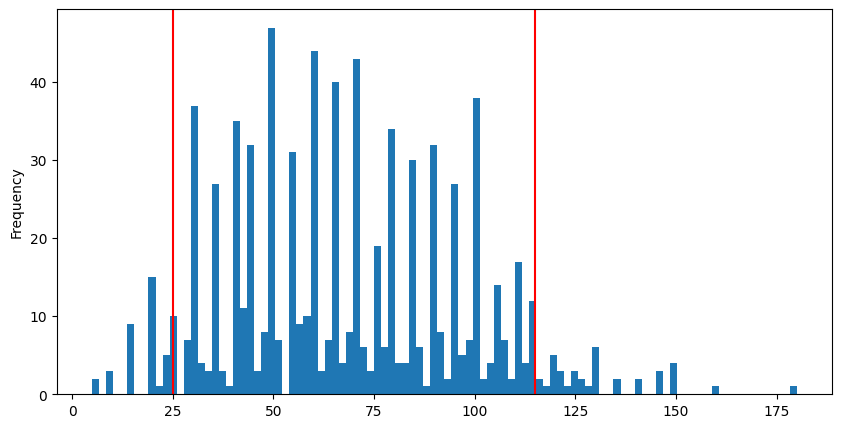

In [269]:
ax = df['Speed'].plot(kind='hist', figsize=(10, 5), bins=100)
ax.axvline(df['Speed'].quantile(.05), color='red')
ax.axvline(df['Speed'].quantile(.95), color='red')

##### Select those pokemons that are either very slow (with `Speed` below the bottom 5%) or very fast (`Speed` above the top 95%).

In [271]:
bottom_5 = df['Speed'].quantile(.05)
top_5 = df['Speed'].quantile(.95)

(bottom_5, top_5)

(np.float64(25.0), np.float64(115.0))

In [276]:
df.query("Speed < @bottom_5 or Speed > @top_5")

# We use '@' to access the variables.

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False
23,18,PidgeotMega Pidgeot,Normal,Flying,579,83,80,80,135,80,121,1,False
44,39,Jigglypuff,Normal,Fairy,270,115,45,20,45,25,20,1,False
56,51,Dugtrio,Ground,NaN,405,35,80,50,50,70,120,1,False
70,65,Alakazam,Psychic,NaN,500,55,50,45,135,95,120,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,658,Greninja,Water,Dark,530,72,95,67,103,71,122,6,False
731,663,Talonflame,Fire,Flying,499,78,81,71,74,69,126,6,False
752,682,Spritzee,Fairy,NaN,341,78,52,60,63,65,23,6,False
771,701,Hawlucha,Fighting,Flying,500,78,92,75,74,63,118,6,False


In [277]:
slow_fast_df = df.loc[
  (df['Speed'] < bottom_5) |
  (df['Speed'] > top_5)
]

slow_fast_df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False
23,18,PidgeotMega Pidgeot,Normal,Flying,579,83,80,80,135,80,121,1,False
44,39,Jigglypuff,Normal,Fairy,270,115,45,20,45,25,20,1,False
56,51,Dugtrio,Ground,NaN,405,35,80,50,50,70,120,1,False
70,65,Alakazam,Psychic,NaN,500,55,50,45,135,95,120,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,658,Greninja,Water,Dark,530,72,95,67,103,71,122,6,False
731,663,Talonflame,Fire,Flying,499,78,81,71,74,69,126,6,False
752,682,Spritzee,Fairy,NaN,341,78,52,60,63,65,23,6,False
771,701,Hawlucha,Fighting,Flying,500,78,92,75,74,63,118,6,False


#### 16. Find the ultra powerful legendary pokemon
##### Take a look at the scatter plot correlating Defese to Attack. What's the name of the pokemon indicated by the red arrow in the plot below.

In [290]:
powerful_legendary = df.loc[
  df['Legendary']].sort_values(by=['Defense', 'Attack'], 
  ascending=[False, True]).head(1)
powerful_legendary

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
414,377,Regirock,Rock,NaN,580,80,100,200,50,100,50,3,True


Text(414    150
Name: Defense, dtype: int64, 414    120
Name: Attack, dtype: int64, "Who's this guy?")

/Users/ashishkhanagwal/Documents/ASHISH/2. TECH/Artificial-Intelligence/.venv/lib/python3.13/site-packages/matplotlib/text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
/Users/ashishkhanagwal/Documents/ASHISH/2. TECH/Artificial-Intelligence/.venv/lib/python3.13/site-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))
/Users/ashishkhanagwal/Documents/ASHISH/2. TECH/Artificial-Intelligence/.venv/lib/python3.13/site-packages/matplotlib/text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/Users/ashishkhanagwal/Documents/ASHISH/2. TECH/Artificial-Int

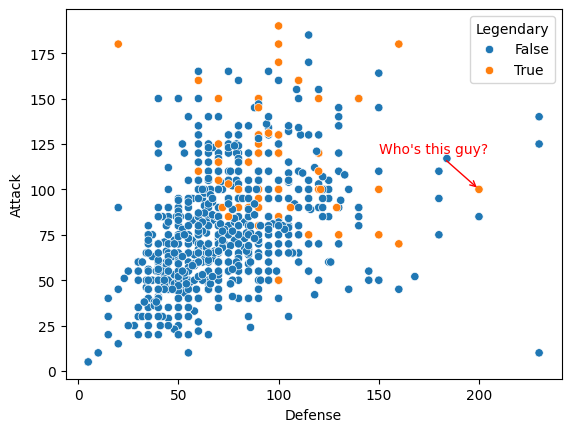

In [291]:
ax = sns.scatterplot(data=df, x='Defense', y='Attack', hue='Legendary')
ax.annotate("Who's this guy?", xy=(powerful_legendary['Defense'], powerful_legendary['Attack']), 
    xytext=(powerful_legendary['Defense']-50, powerful_legendary['Attack'] + 20), color='red',
    arrowprops=dict(arrowstyle='->', color='red'))

In [292]:
powerful_legendary

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
414,377,Regirock,Rock,NaN,580,80,100,200,50,100,50,3,True
